# Entrenando un modelos de regresión con  Scikit-Learn.

Este proyecto trata del entrenamiento de un modelo de regresión lineal simple. El objetivo es entrenar un modelo para generalizar la respuesta **satisfacción de vida**, usando el **producto interno bruto por cápita**.

## Cargando y preparando los datos.

In [1]:
#Accedemos a google Drive para cargar los datos
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [7]:
#Importamos los modulos necesarios
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression

In [12]:
#Cargamos los datos
df_satisfaccion_vida = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/GitHub/Entrenando y ejecutando un modelo lineal usando Scikit-Learn/lifesat.csv")

In [18]:
#Miramos las primeras filas con el método head()
df_satisfaccion_vida.head()

,Country,GDP per capita (USD),Life satisfaction
0,Russia,26456.387938,5.8
1,Greece,27287.083401,5.4
2,Turkey,28384.987785,5.5
3,Latvia,29932.493910,5.9
4,Hungary,31007.768407,5.6


Como queremos entrenar nuestro modelo con la variable *x*, **GDP per capita (USD)**, entonces creamos el arreglo *x* asignandole los valores de la columna **GDP per capita (USD)**.

La variable de respuesta es **Life satisfaction** que se la asignamos a *y*

In [24]:
x = df_satisfaccion_vida[["GDP per capita (USD)"]].values
y = df_satisfaccion_vida[["Life satisfaction"]].values

## Visualizando los datos.

Podemos crear una gráfica de dispersión.

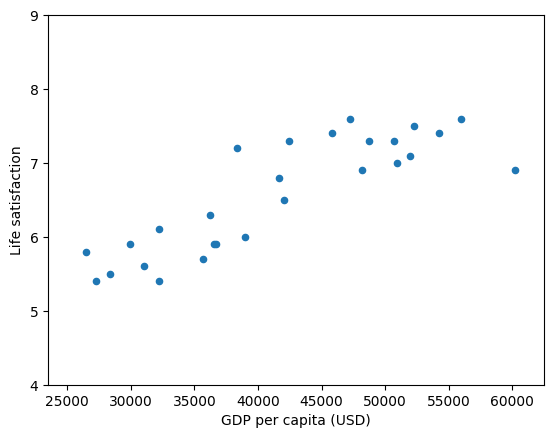

In [31]:
df_satisfaccion_vida.plot(kind='scatter', grid=False,
                          x='GDP per capita (USD)', y='Life satisfaction')
plt.axis([23_500, 62_500, 4, 9])
plt.show()

Podemos ver cierta tendencia a ser más feliz a medida que el ingreso por capita aumenta.

## Selección y entrenado del modelo

In [32]:
#Seleccionamos un modelo
modelo_regresion_lineal = LinearRegression()

In [33]:
#Entrenamos el modelo
modelo_regresion_lineal.fit(x,y)

LinearRegression()

## Hacer una predicción

Probemos para la isla Chipre

In [40]:
x_chipre = [[37_655.2]]
print(modelo_regresion_lineal.predict(x_chipre))

[[6.30165767]]


Este nos predice que obtenemos una satisfacción de 6.30/10.

Ahora veamos que pasa para México.

In [41]:
x_mexico= [[14_185.8]]
print(modelo_regresion_lineal.predict(x_mexico))

[[4.71069058]]


En este caso la predicción del modelo de regresión lineal es de 4.7/10.

# Usando K-nearest neighbors

En vez de usar un la refresión lineal podemos usar K-nearest neighbors y para eso importamos el siguiente modulo

In [37]:
from sklearn.neighbors import KNeighborsRegressor

In [38]:
modelo_k_nearest_neighbors = KNeighborsRegressor(n_neighbors=5)
modelo_k_nearest_neighbors.fit(x,y)

KNeighborsRegressor()

In [47]:
#Para Chipre
modelo_k_nearest_neighbors.predict((x_chipre))

array([[6.26]])

In [49]:
#Para México
modelo_k_nearest_neighbors.predict((x_mexico))

array([[5.64]])

He entrenado un modelo de regresión lineal y un modelo de k-nearest neighbors, ambos modelos nos entregan buenas predicciones basadas en los datos propocionados.

# Limitaciones

Por supuesto, tenemos limitaciones al hacer una buena predicción pues nos estamos basando unicamente el la variable de PIB por capita, sin embargo otras variables pueden ser importantes a considarar como: sus relaciones personales, tasa de empleo, salud, etc.